## Importing libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [8]:
data=pd.read_csv(r"C:\Users\druth\OneDrive\Desktop\Projects\fake news detection\Fake.csv")

In [9]:
df= pd.DataFrame(data)

In [10]:
df

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


In [15]:
df.head(5)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [17]:
df.shape

(23481, 4)

In [19]:
df.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [23]:
df.describe().T

,count,unique,top,freq
title,23481,17903,MEDIA IGNORES Time That Bill Clinton FIRED His...,6
text,23481,17455,,626
subject,23481,6,News,9050
date,23481,1681,"May 10, 2017",46


In [25]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [27]:
df["subject"].value_counts()

subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

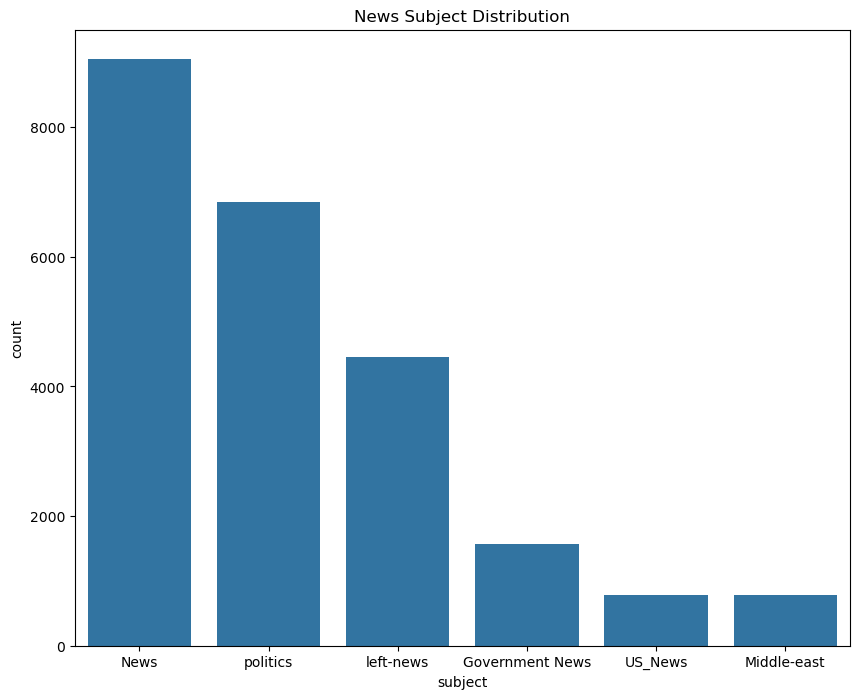

In [29]:
plt.figure(figsize=(10,8))
sns.countplot(data=df,x='subject',order=df['subject'].value_counts().index)
plt.title("News Subject Distribution")
plt.show()

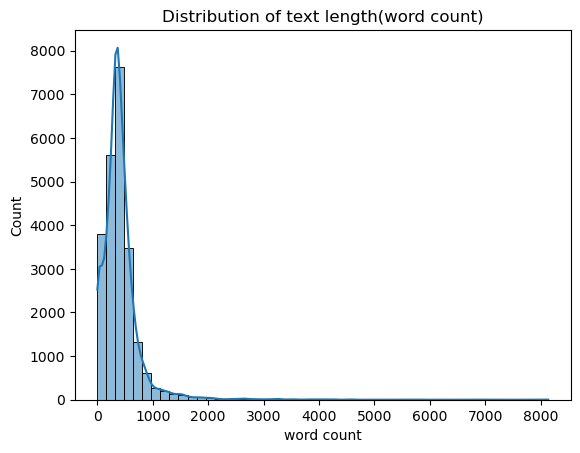

In [30]:
df['text_length']=df['text'].apply(lambda x:len(str(x).split()))
sns.histplot(df['text_length'],bins=50,kde=True)
plt.title("Distribution of text length(word count)")
plt.xlabel("word count")
plt.show()

## Most Common Words in Titles

In [34]:
!pip install wordcloud
from wordcloud import WordCloud,STOPWORDS


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


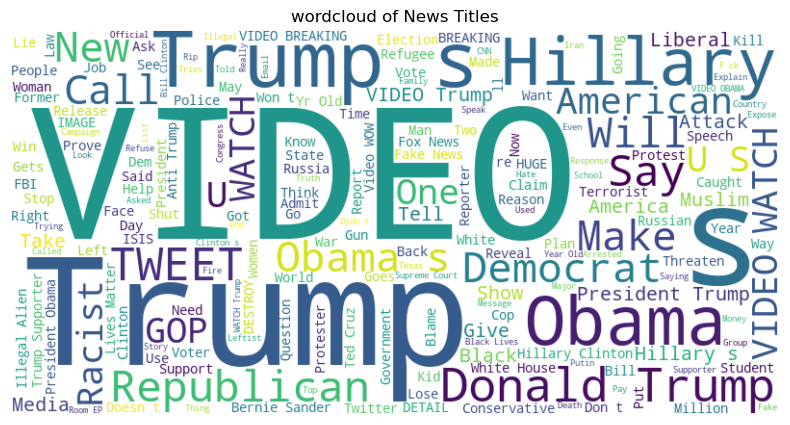

In [36]:
text_titles=''.join(df['title'].dropna().astype(str))
wordcloud=WordCloud(stopwords=STOPWORDS,background_color='white',height=400,width=800).generate(text_titles)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title("wordcloud of News Titles")
plt.show()

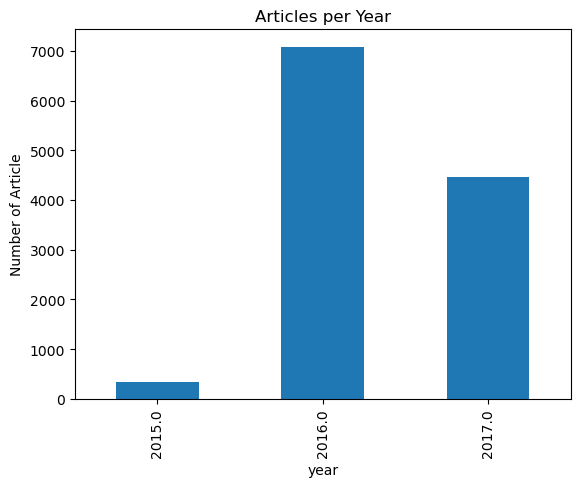

In [43]:
df['date']=pd.to_datetime(df['date'],errors='coerce')
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month

df['year'].value_counts().sort_index().plot(kind='bar',title='Articles per Year')
plt.xlabel('year')
plt.ylabel('Number of Article')
plt.show()

In [ ]:
sns.boxplot(data=df,x='subject',)